In [184]:
# import Packages
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from tavily import TavilyClient
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
from tavily import TavilyClient
from dotenv import load_dotenv
from pprint import pprint
from typing import Literal
import os

In [162]:
# Get Env Vars
load_dotenv()
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [163]:
# Define Agent Brain
groq_model = ChatGroq(model="llama-3.1-8b-instant", temperature=0, api_key=GROQ_API_KEY)

In [ ]:
# Agent State
class AgentState(TypedDict):
    response: str
    question: str
    user_feedback: str
    status: Literal["approved", "feedback"]

In [165]:
SYS_PROMPT = """You are a helpful AI assistant that can answer any question by searching the web if needed. 
Provide accurate, concise, and helpful responses. When you need current information, use the search tool."""

In [ ]:
# Define Assistant Draft
def assistant_draft(state: AgentState):
    print("assistant_draft ...")
    print(state)
    messages = [HumanMessage(state["question"]), SystemMessage(SYS_PROMPT)]
    response = groq_model.invoke(input=messages)
    return {"response": response.content}
    

In [167]:
def human_feedback(state: AgentState):
    pass

In [ ]:
# Define Assistant Finalizer
def assistant_finalize(state: AgentState):
    system_message = """
        You are an AI assistant. The user has approved your draft. Carefully 
        review your reply and make any final improvements to clarity, tone, and 
        completeness. Ensure the response is polished, professional, and ready 
        to be delivered as the final answer.
    """
    messages = [SystemMessage(system_message)] + state["messages"]
    print("Step 3")


In [185]:
def feedback_router(state: AgentState):
    if state["status"] == "approved":
        return "assistant_finalize"
    return "assistant_draft"

In [169]:
# Build the Graph
builder = StateGraph(AgentState)

In [187]:
builder.add_node("assistant_draft", assistant_draft)
builder.add_node("human_feedback", human_feedback)
builder.add_node("assistant_finalize", assistant_finalize)

builder.add_edge(START, "assistant_draft")
builder.add_edge("assistant_draft", "human_feedback")
builder.add_conditional_edges("human_feedback", feedback_router,
        {
            "assistant_finalize": "assistant_finalize",
            "assistant_draft": "assistant_draft"
        })
builder.add_edge("human_feedback", "assistant_finalize")
builder.add_edge("assistant_finalize", END)


Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `assistant_draft` already present.

In [179]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [180]:
# Workflow Will stop before reach to human_feedback node
graph = builder.compile(checkpointer = checkpointer, interrupt_before=["human_feedback"])

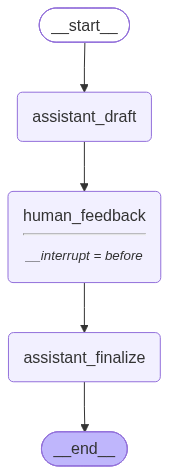

In [181]:
from IPython.display import Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [183]:
thread = {"configurable": {"thread_id": 1}}
user_input = input("Tell me how you want to udpate this state ?")
graph.update_state(thread, {"user_feedback": user_input}, as_node="human_feedback")

graph.get_state(thread).next

('assistant_finalize',)

In [173]:
config = {"configurable": {"thread_id": "1"}}

result = graph.invoke(
    {
        "question": "What is Morroocan President ?",
        "response": "",
        "human_feedback": ""
    },
    config=config
)


Step 1


In [174]:
from IPython.display import Markdown
display(Markdown(result["response"]))